In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from scipy import signal
from scipy.signal import detrend, windows
from scipy.special import j0
from scipy.interpolate import interp1d
import glob

#### All Utility Functions

In [ ]:
def moving_average_numpy(data, window_size):
    kernel = np.ones(window_size) / window_size
    smoothed_data = np.convolve(data, kernel, mode='same')
    return smoothed_data

def process_signals(data_array, taper_percent=0.05):
    detrended_data = detrend(data_array)
    taper_window = windows.tukey(len(detrended_data), alpha=taper_percent)
    tapered_data = detrended_data * taper_window

    return tapered_data

# Function to compute cross-power spectrum
def compute_cross_power_spectrum(r1, r2, delta):
    # Compute FFTs
    fft_r1 = np.fft.fft(r1)
    fft_r2 = np.fft.fft(r2)

    # Cross-power spectrum = FFT(R1) * conj(FFT(R2))
    cross_power = fft_r1 * np.conj(fft_r2)

    # Frequency axis
    freqs = np.fft.fftfreq(len(r1), d=delta)

    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    # cross_power_pos = cross_power[pos_mask]

    # magnitude = np.abs(cross_power_pos)
    # coherence = cross_power/(np.abs(fft_r1)*np.abs(fft_r2))
    den = np.abs(fft_r1) * np.abs(fft_r2)
    coherence = np.zeros_like(cross_power, dtype=np.complex128)
    mask = den > 0
    coherence[mask] = cross_power[mask] / den[mask]

    return freqs_pos, cross_power[pos_mask],  coherence[pos_mask]


def test_for_coherence_and_ts(root_path,expname,output_dir,smoothing=10):
    DELTA = 0.5 

    wedges_r1_ts = []
    wedges_r2_ts = []
    wedges_freq_ccf = []
    wedges_freq_axis = []

    file_root_path = os.path.join(root_path, expname, output_dir)
    file_root_path1 = f'{file_root_path}/*/*_R1_Z.txt'
    file_root_path2 = f'{file_root_path}/*/*_R2_Z.txt'
    all_files1 = glob.glob(file_root_path1)
    all_files2 = glob.glob(file_root_path2)
    nfiles = len(all_files1)
    i=1
    for f1,f2 in zip(all_files1, all_files2):
        r1_file = f1
        r2_file = f2
        #print(r1_file); print(r2_file);

        r1 = np.loadtxt(r1_file)
        r2 = np.loadtxt(r2_file)
        r1 = np.array(r1)
        r2 = np.array(r2)
        ## append for time series stack gets added here for r1 and r2

        r1 = process_signals(r1)
        r2 = process_signals(r2)
        
        wedges_r1_ts.append(r1)
        wedges_r2_ts.append(r2)

        # Compute cross-power spectrum
        freqs, cross_power, coherence = compute_cross_power_spectrum(r1, r2, DELTA)
        wedges_freq_ccf.append(coherence)
        wedges_freq_axis.append(freqs)
        
        # Create individual plot
        if i<=5:
            plt.figure(figsize=(10, 3))
            plt.subplot(1,2,1)
            plt.plot(r1, 'b-', linewidth=0.8)
        
            plt.subplot(1,2,2)
            plt.plot(freqs, np.real(coherence), 'b-', linewidth=0.8)
            plt.xlabel('Frequency (Hz)', fontsize=12)
            plt.ylabel('Coherence', fontsize=12)
            plt.title(f'Coherence - Wedge {i}', fontsize=14, fontweight='bold')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
        
            plt.show()
        i+=1

    ## Note Bk: Do not save the coherence with the moving average computation
    print(np.array(wedges_freq_ccf).shape)
    final_coherence_mean = np.mean(np.array(wedges_freq_ccf), axis=0) 
    final_coherence_mean = moving_average_numpy(final_coherence_mean, smoothing)
    final_coherence_freqs = wedges_freq_axis[0]

    ## save the stacked time series (wedges_r1_ts, wedges_r2_ts) and freq domain (wedges_freq_axis,wedges_freq_ccf) 
    ## and coherence (wedges_freq_ccf, final_coherence_freqs)

    ## here iclude the new code for computing time series CCF and save it.
    ## then add the code for FTAN computation
    ## and your code for 2d Ground Truth using group vel, 0 mode and generation of image that u have u have previously with earth model
    ## concantenate the sources in the results folder as ione singel file (not plot)

    # Create stacked plot
    plt.figure(figsize=(10, 3))
    plt.plot(final_coherence_freqs, np.real(final_coherence_mean), 'r-', linewidth=1.2)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Cross-Power Magnitude', fontsize=12)
    plt.title('Cross-Power Spectrum - Stacked', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xlim(0, 0.5)  # Focus on 0-0.5 Hz
    plt.tight_layout()
    plt.show()

    return final_coherence_freqs, final_coherence_mean

def compute_greensfunc(pvelfile='SDISPR.ASC', r=200, ):
    pvel_df = pd.read_csv(pvelfile, sep='\s+', header=0)
    pvel_df = pvel_df.sort_values(by='FREQUENCY(Hz)')
    pvel_df_fund = pvel_df[pvel_df['RMODE']==0]

    pvel_freq = pvel_df_fund['FREQUENCY(Hz)']
    pvel_vals = pvel_df_fund['C(KM/S)']

    r = 200;
    w = 2 * np.pi * pvel_freq;
    bess_arr = (w * r)/pvel_vals;
    greenf = j0(bess_arr);

    return pvel_freq, greenf

def plot_bessel_fit(final_coherence_freqs, final_coherence_mean, pvel_freq, greenf):
    idxx = (final_coherence_freqs>=0.02) & (final_coherence_freqs<=0.5)
    final_coherence_freqs_plot  = final_coherence_freqs[idxx]
    final_coherence_mean_plot = final_coherence_mean[idxx]

    interp_f = interp1d(pvel_freq, greenf, kind='linear')
    interp_gf = interp_f(final_coherence_freqs_plot)

    plt.figure(figsize=(12, 4))
    plt.plot(final_coherence_freqs_plot, np.real(final_coherence_mean_plot), 'r-', linewidth=1, label='ccf')
    plt.plot(final_coherence_freqs_plot, interp_gf, 'b--', linewidth=1, label='ref besse')
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Coherence', fontsize=12)
    plt.legend(); plt.show()

#### Experiment 1 Point Forces 10 Wedges

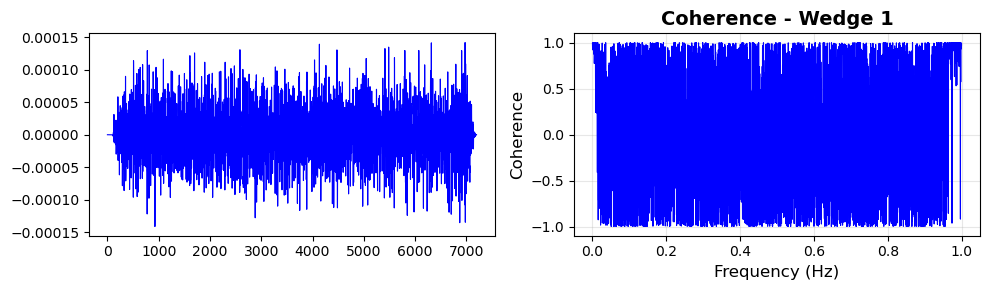

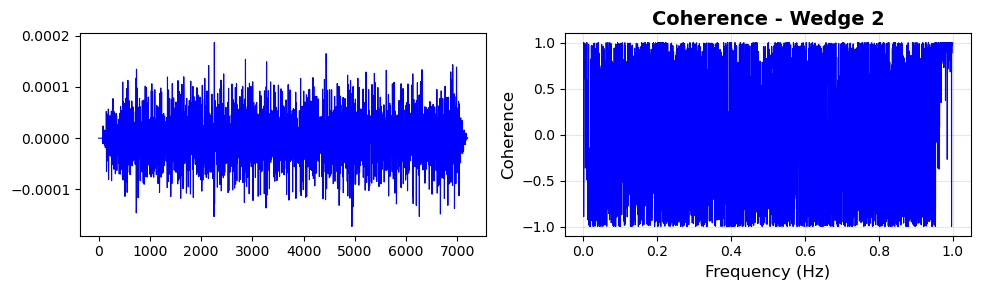

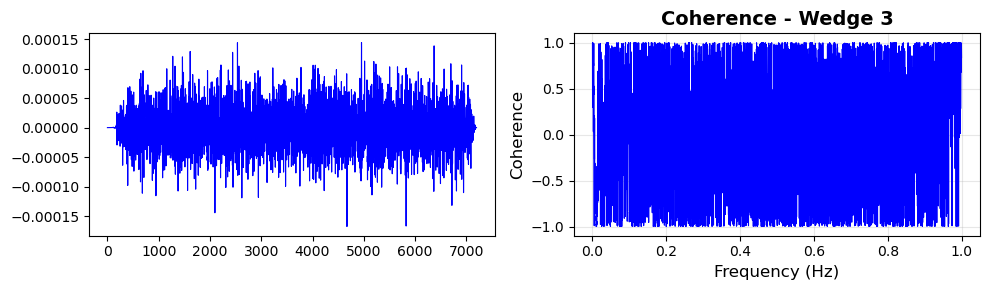

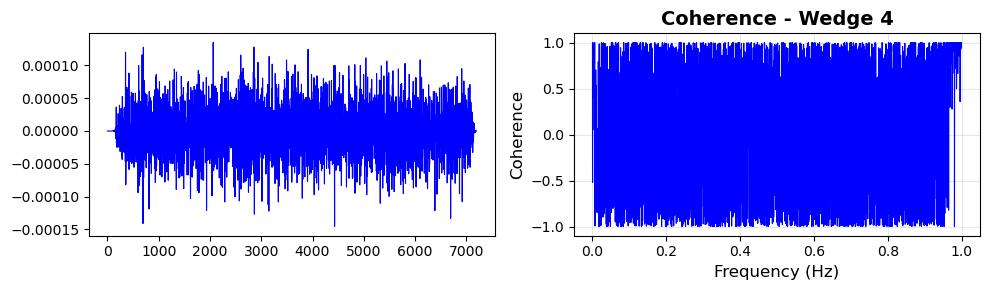

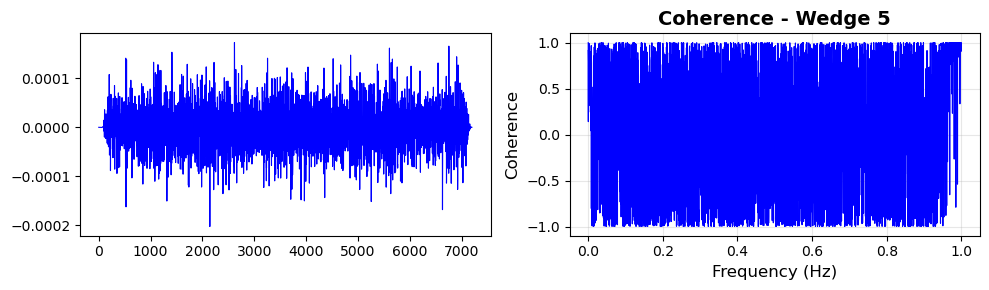

(10, 3599)


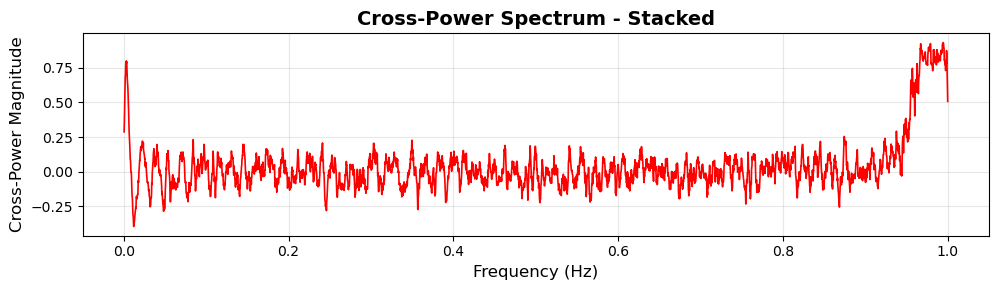

In [42]:
root_path = '/scratch/tolugboj_lab/Prj_Wavenet/epic_production'
expname = "experiment_1_point_forces"
output_dir = 'output_10wedges'

final_coherence_freqs, final_coherence_mean = test_for_coherence_and_ts(root_path,expname,output_dir)
pvel_freq, greenf = compute_greensfunc(pvelfile='/scratch/tolugboj_lab/Prj_Wavenet/epic_related/SDISPR.ASC', r=200)

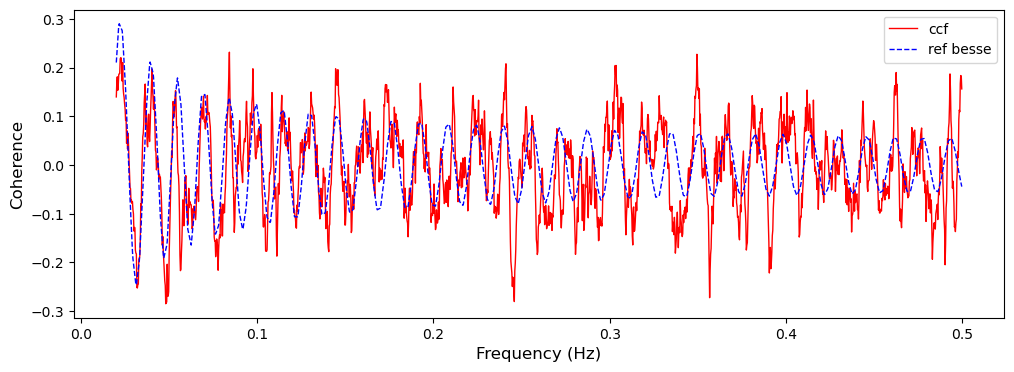

In [46]:
plot_bessel_fit(final_coherence_freqs, final_coherence_mean, pvel_freq, greenf)

#### Experiment 1 Point Forces 180 Wedges

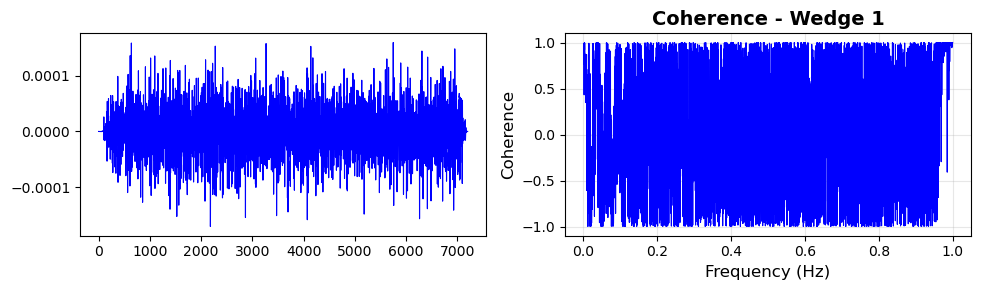

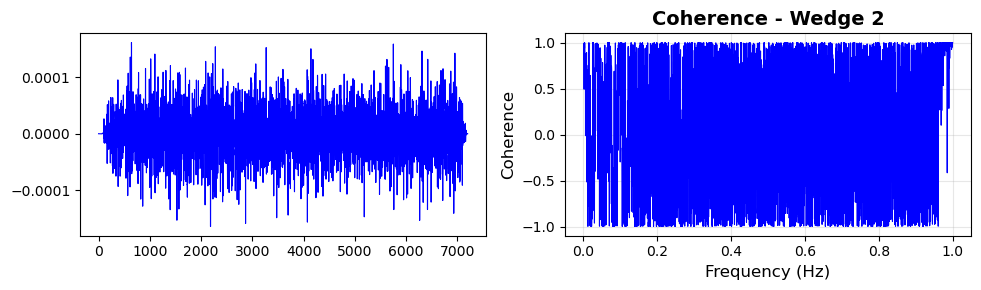

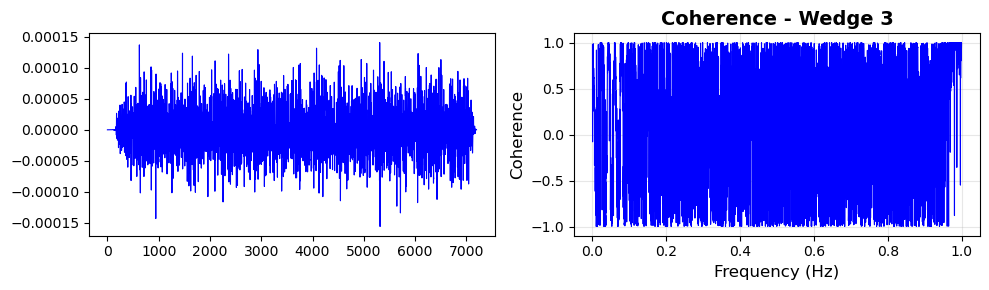

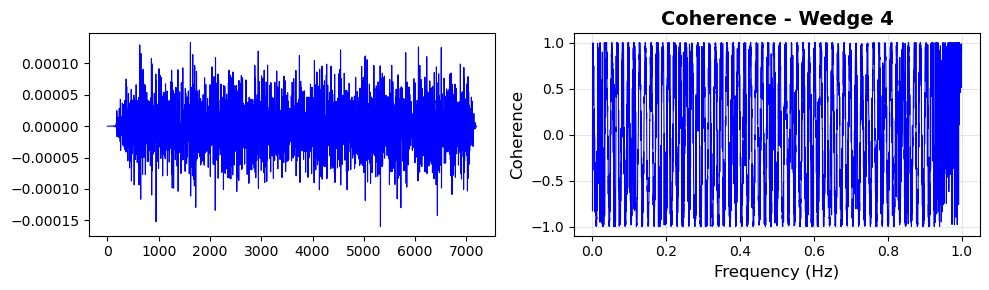

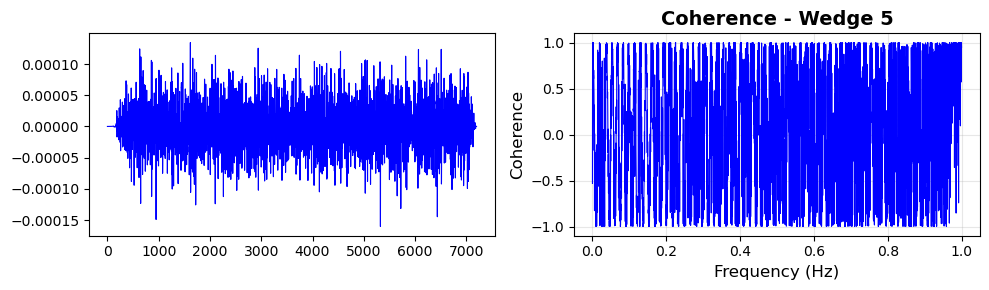

(180, 3599)


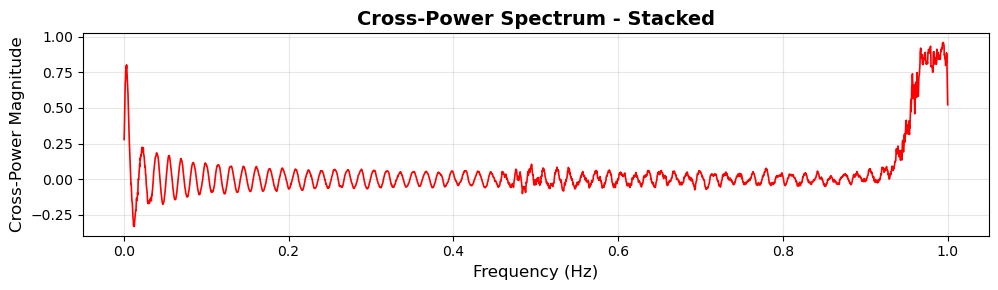

In [47]:
root_path = '/scratch/tolugboj_lab/Prj_Wavenet/epic_production'
expname = "experiment_1_point_forces"
output_dir = 'output_180wedges'

final_coherence_freqs, final_coherence_mean = test_for_coherence_and_ts(root_path,expname,output_dir)
pvel_freq, greenf = compute_greensfunc(pvelfile='/scratch/tolugboj_lab/Prj_Wavenet/epic_related/SDISPR.ASC', r=200)

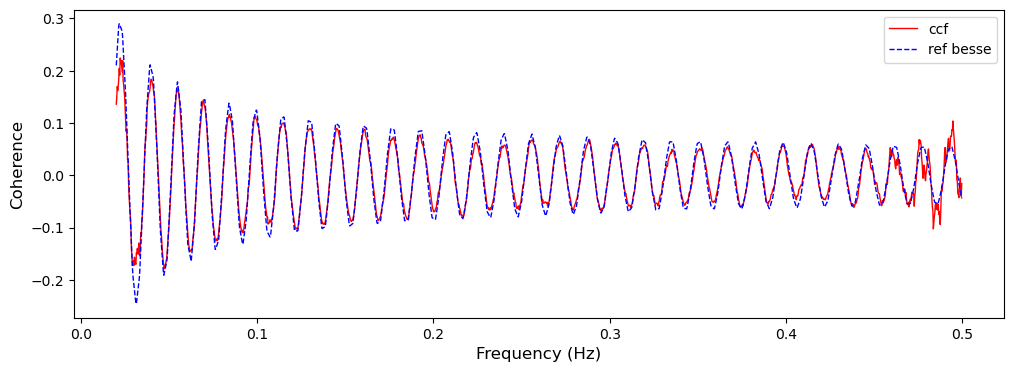

In [48]:
plot_bessel_fit(final_coherence_freqs, final_coherence_mean, pvel_freq, greenf)

#### Experiment 2 Explosion 10 Wedges

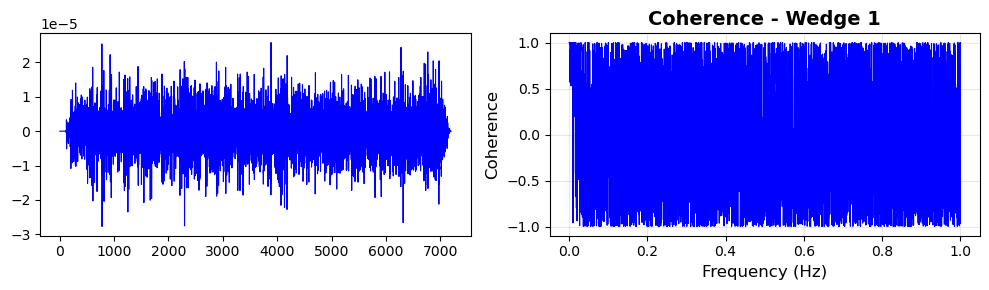

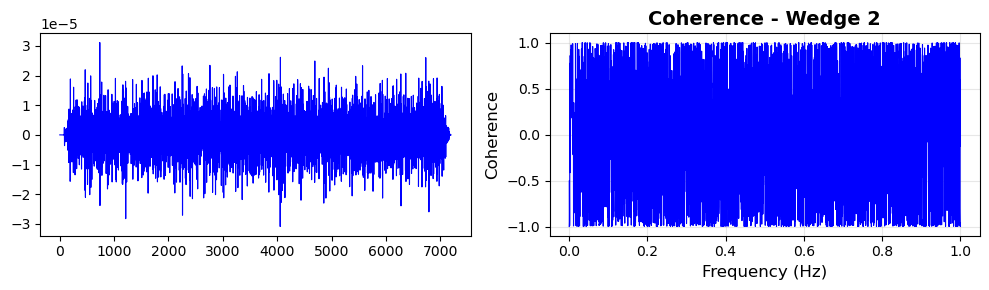

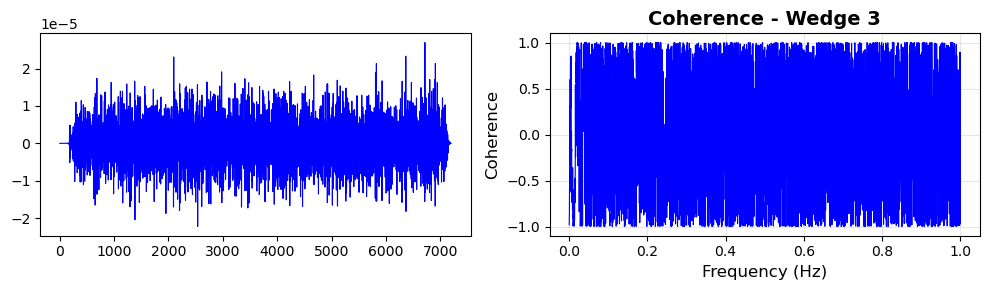

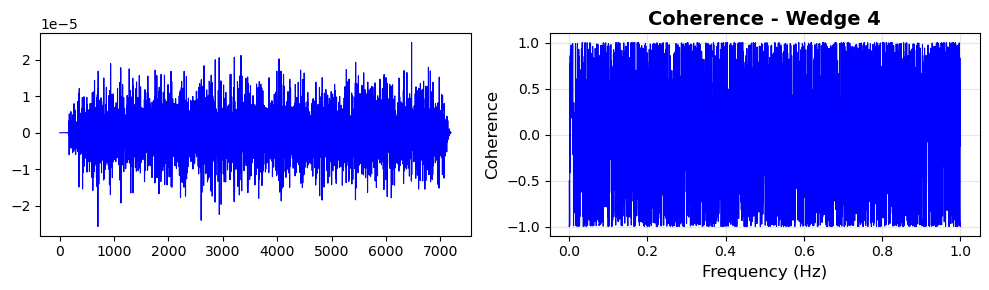

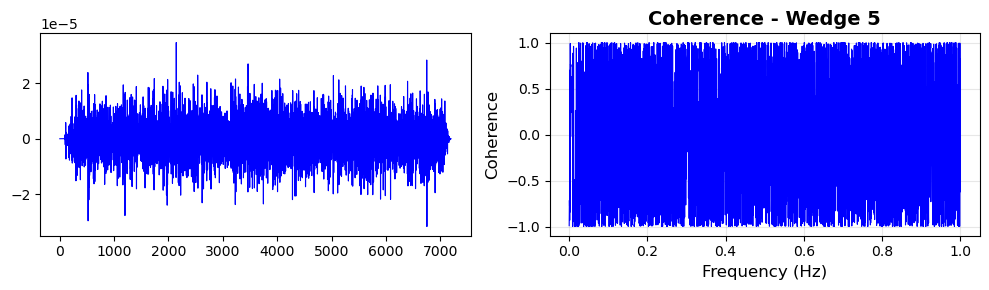

(10, 3599)


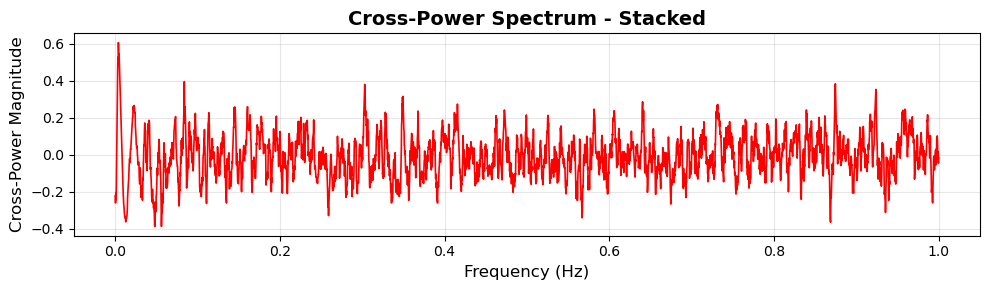

In [49]:
root_path = '/scratch/tolugboj_lab/Prj_Wavenet/epic_production'
expname = "experiment_2_explosion"
output_dir = 'output_10wedges'

final_coherence_freqs, final_coherence_mean = test_for_coherence_and_ts(root_path,expname,output_dir)
pvel_freq, greenf = compute_greensfunc(pvelfile='/scratch/tolugboj_lab/Prj_Wavenet/epic_related/SDISPR.ASC', r=200)

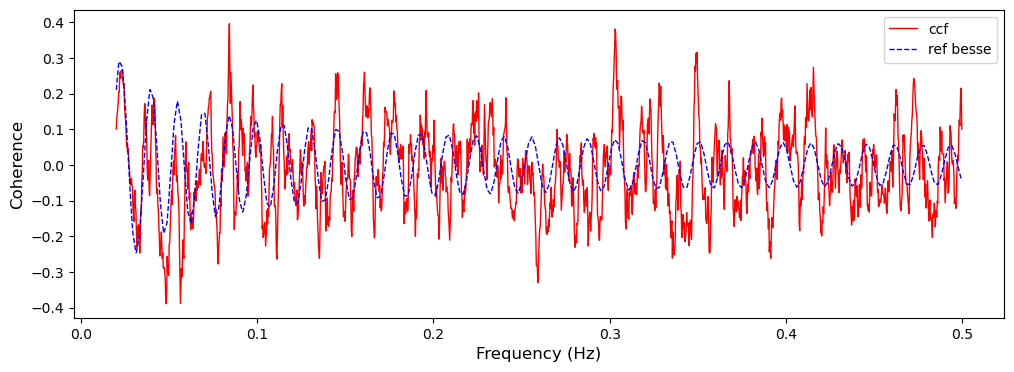

In [50]:
plot_bessel_fit(final_coherence_freqs, final_coherence_mean, pvel_freq, greenf)

#### Experiment 2 Explosion 180 Wedges

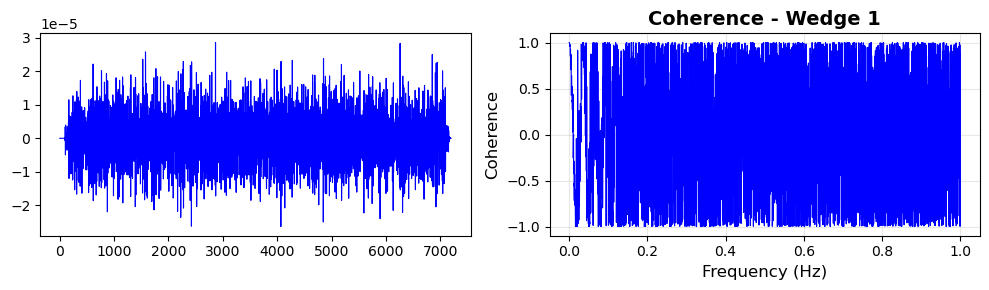

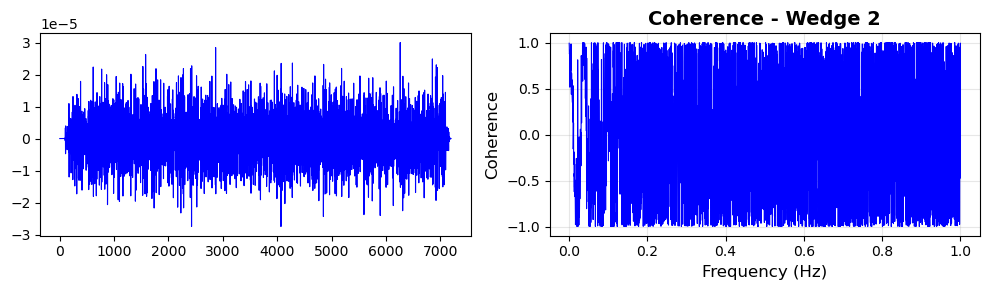

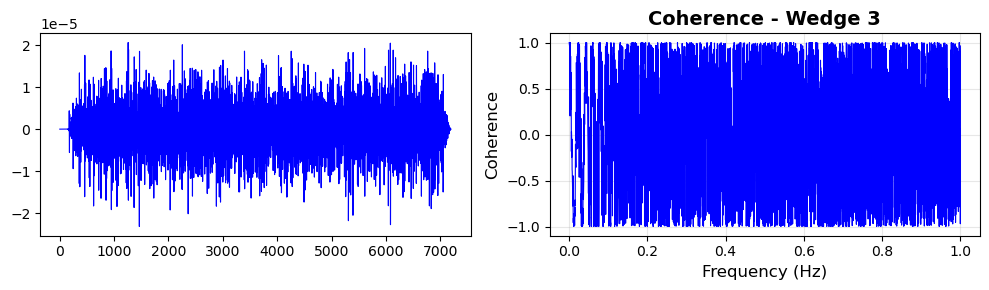

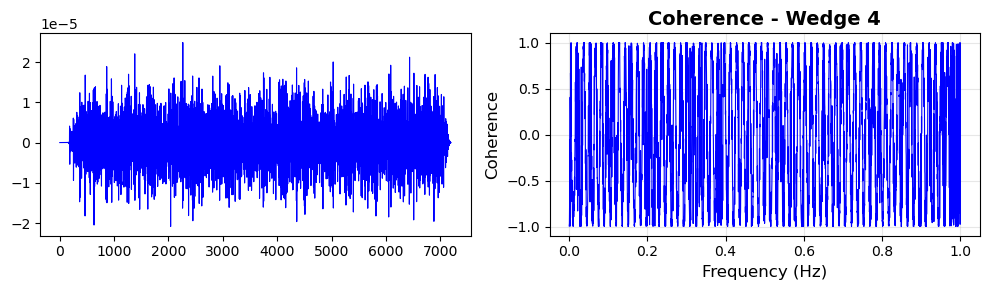

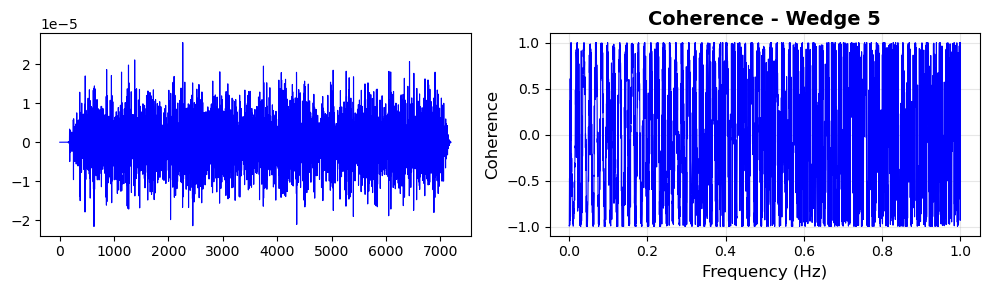

(180, 3599)


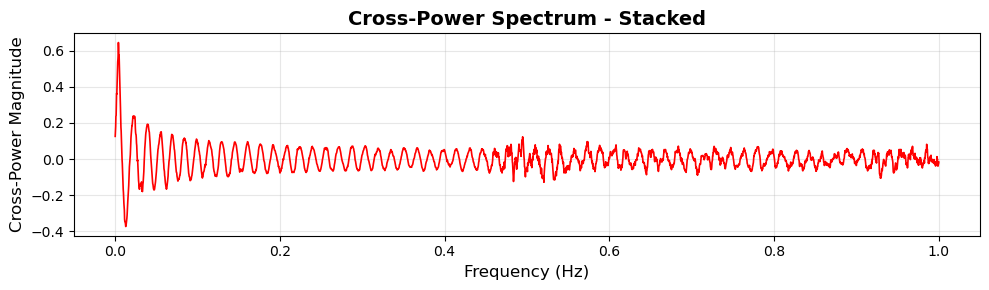

In [51]:
root_path = '/scratch/tolugboj_lab/Prj_Wavenet/epic_production'
expname = "experiment_2_explosion"
output_dir = 'output_180wedges'

final_coherence_freqs, final_coherence_mean = test_for_coherence_and_ts(root_path,expname,output_dir)
pvel_freq, greenf = compute_greensfunc(pvelfile='/scratch/tolugboj_lab/Prj_Wavenet/epic_related/SDISPR.ASC', r=200)

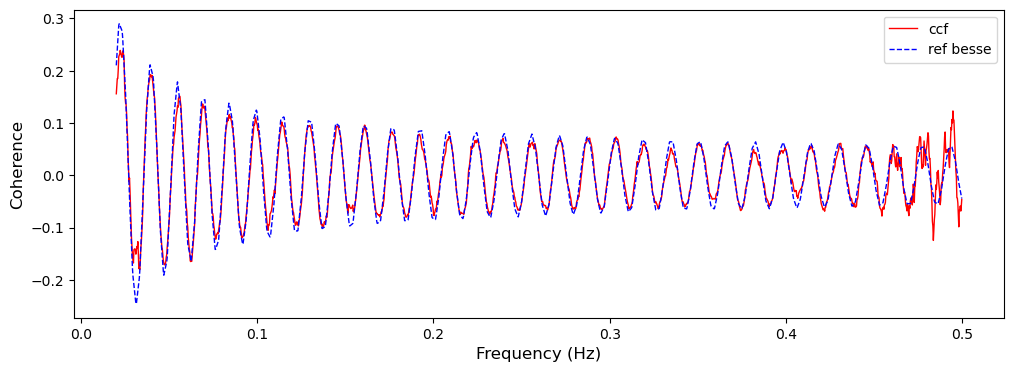

In [52]:
plot_bessel_fit(final_coherence_freqs, final_coherence_mean, pvel_freq, greenf)

#### For BK (later)

Try to see play with the idea os SNR, where 1 single wedge surrounding the whole 360 degree region with 10^6-10^8 number of source, making any difference or not.